# Cybersecurity: Suspicious Web Threat Interactions

**Objective:** Analyze AWS CloudWatch web traffic logs to detect and classify suspicious activities using machine learning techniques.

**Author:** Pawan Khot
**Tools Used:** Python, Pandas, Seaborn, Scikit-learn, TensorFlow, Matplotlib, NetworkX  
**Models Used:** Isolation Forest, Random Forest, Neural Networks  
**Dataset Source:** [CloudWatch Traffic Dataset](https://drive.google.com/file/d/1-OpnR9FK8EqGuLFB1k45ctPbl-vuZnC-/view?usp=sharing)


In [7]:
import pandas as pd

df = pd.read_csv('CloudWatch_Traffic_Web_Attack.csv')  # Replace with your file path
df.head()

,bytes_in,bytes_out,creation_time,end_time,src_ip,src_ip_country_code,protocol,response.code,dst_port,dst_ip,rule_names,observation_name,source.meta,source.name,time,detection_types
0,5602,12990,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,147.161.161.82,AE,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
1,30912,18186,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,165.225.33.6,US,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
2,28506,13468,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,165.225.212.255,CA,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
3,30546,14278,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,136.226.64.114,US,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
4,6526,13892,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,165.225.240.79,NL,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule


**Data Cleaning:**

In [ ]:
df = df.drop_duplicates()

df['creation_time'] = pd.to_datetime(df['creation_time'])
df['end_time'] = pd.to_datetime(df['end_time'])
df['time'] = pd.to_datetime(df['time'])
df['src_ip_country_code'] = df['src_ip_country_code'].str.upper()
df.info()


**Exploratory Data Analysis (EDA):**

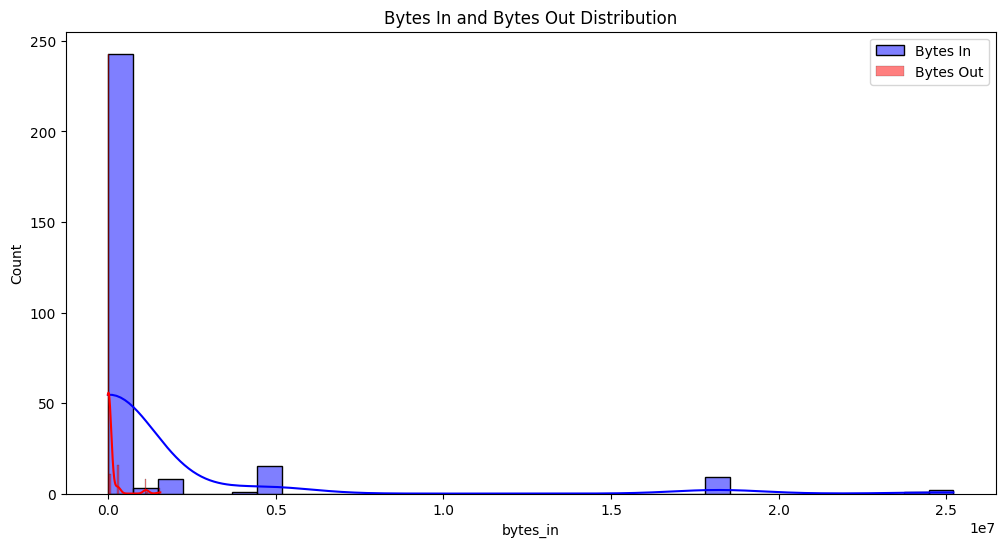

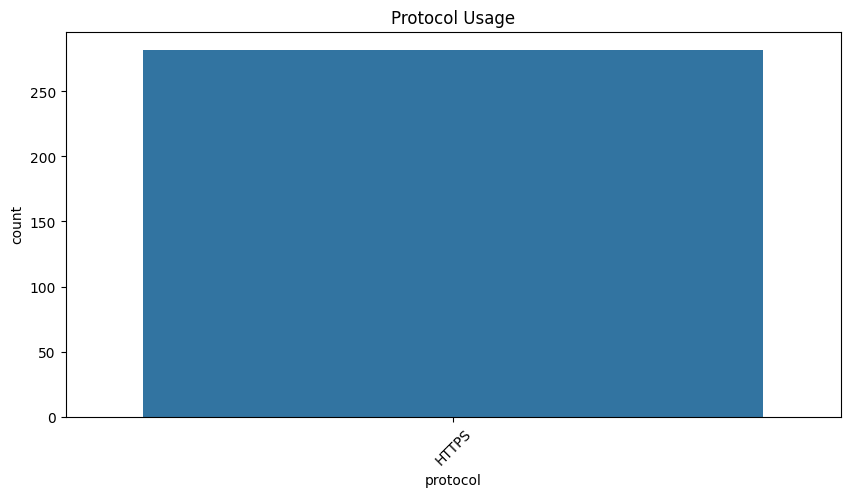

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bytes in/out distribution
plt.figure(figsize=(12,6))
sns.histplot(df['bytes_in'], kde=True, color='blue', label='Bytes In')
sns.histplot(df['bytes_out'], kde=True, color='red', label='Bytes Out')
plt.legend()
plt.title('Bytes In and Bytes Out Distribution')
plt.show()

# Protocol usage
plt.figure(figsize=(10,5))
sns.countplot(x='protocol', data=df)
plt.title('Protocol Usage')
plt.xticks(rotation=45)
plt.show()


**Feature Engineering:**

In [11]:
# Ensure datetime conversion if not already done
if df['creation_time'].dtype == 'O':
	df['creation_time'] = pd.to_datetime(df['creation_time'])
if df['end_time'].dtype == 'O':
	df['end_time'] = pd.to_datetime(df['end_time'])

df['duration_seconds'] = (df['end_time'] - df['creation_time']).dt.total_seconds()
df['avg_packet_size'] = (df['bytes_in'] + df['bytes_out']) / df['duration_seconds']


**Visualization of Suspicious Activity:**

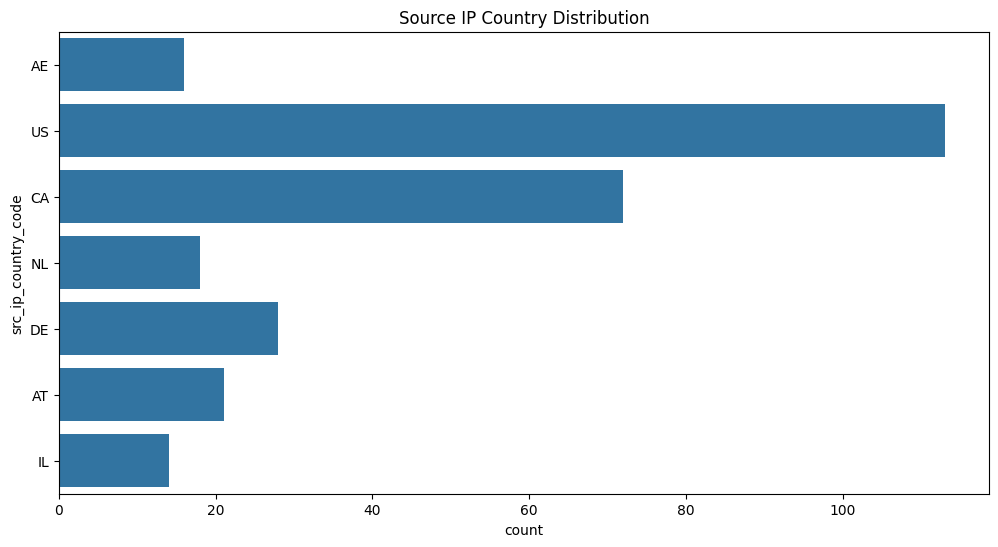

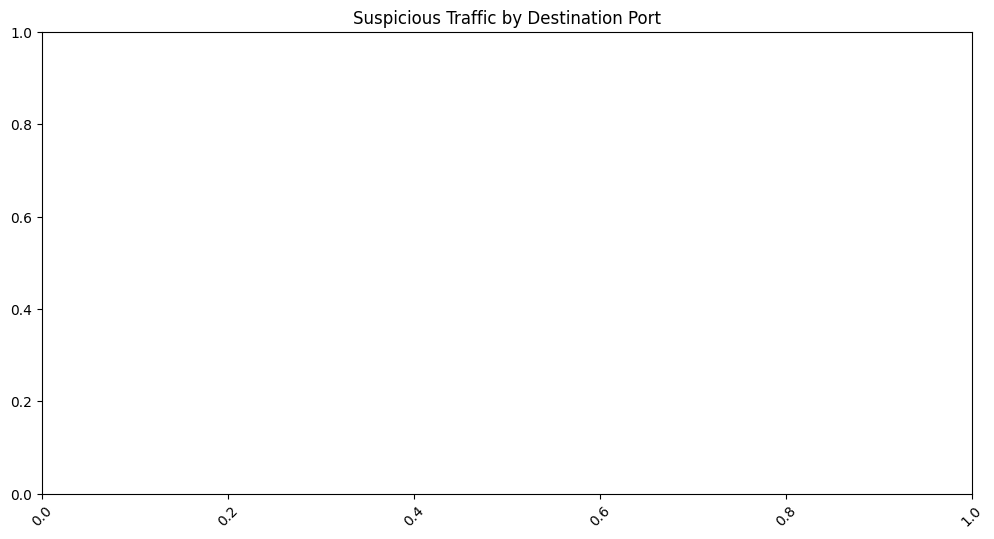

In [12]:
# By country
plt.figure(figsize=(12,6))
sns.countplot(y='src_ip_country_code', data=df)
plt.title('Source IP Country Distribution')
plt.show()

# By destination port for suspicious traffic
plt.figure(figsize=(12,6))
sns.countplot(x='dst_port', data=df[df['detection_types'] == 'Suspicious'])
plt.title('Suspicious Traffic by Destination Port')
plt.xticks(rotation=45)
plt.show()


**Isolation Forest for Anomaly Detection:**

In [15]:
from sklearn.ensemble import IsolationForest

# Use existing 'duration_seconds' and 'avg_packet_size' columns
features = df[['bytes_in', 'bytes_out', 'duration_seconds', 'avg_packet_size']]
model = IsolationForest(contamination=0.05, random_state=42)
df['anomaly'] = model.fit_predict(features)
df['anomaly'] = df['anomaly'].apply(lambda x: 'Suspicious' if x == -1 else 'Normal')
